# 08 — Evaluate generation quality: FID + visual (Phase 9)

**Goal:** Quantitatively compare CVAE samples vs cGAN samples vs real images, per class, so we can decide which generator's output to use for augmenting the training set in Phase 10.
## Design choices

1. **Metric: FID (Fréchet Inception Distance).** Inception Score is the other common choice, but IS is calibrated on ImageNet classes — skin lesions are not in ImageNet, so IS would be misleading. FID compares *distributions of Inception-v3 features* between real and synthetic, so the absolute Inception classes don't matter — it just needs a fixed feature extractor.

2. **Per-class FID, not just global.** A global score would hide which classes work. The whole point of Phase 8 was rare-class augmentation, so we need to know e.g. whether DF samples are actually useful or pure noise.

3. **Sample-size caveat.** FID is *biased downward* on small samples (standard practice uses 10k+ per side; we have 115 real DF). So:
   - FID values **are comparable within a class** (CVAE-vs-cGAN for DF — same sample size on the real side).
   - FID values **are NOT comparable across classes** (DF's FID will look worse than NV's purely because of fewer real samples).
   - This caveat is noted in the output and should appear in the report.

4. **Real images = TRAIN split only**, never test. Test stays untouched for Phase 10 evaluation.

5. **Library: `torchmetrics.image.fid.FrechetInceptionDistance`.** Wraps Inception-v3, accumulates feature stats internally, well-maintained. Install with `pip install torchmetrics[image]`.

**Outputs:**
- `results/logs/fid_scores.csv` — table of FID per (class, source)
- `results/plots/fid_per_class.png` — bar chart
- `results/plots/real_vs_synthetic_grid.png` — side-by-side comparison (real | cvae | cgan), one row per class

## 1. Setup, paths

If `torchmetrics` isn't installed, run `pip install "torchmetrics[image]"` once in the venv.

In [1]:
import sys
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import transforms
from torchmetrics.image.fid import FrechetInceptionDistance

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import CLASS_NAMES   # noqa: E402

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

RESULTS    = PROJECT_ROOT / 'results'
SYNTH_ROOT = PROJECT_ROOT / 'data' / 'synthetic'
IMAGES_DIR = PROJECT_ROOT / 'data' / 'raw' / 'ISIC2018_Task3_Training_Input'
SPLITS_CSV = PROJECT_ROOT / 'data' / 'processed' / 'splits.csv'
MANIFEST   = SYNTH_ROOT / 'synthetic_manifest.csv'

(RESULTS / 'logs').mkdir(parents=True, exist_ok=True)
(RESULTS / 'plots').mkdir(parents=True, exist_ok=True)

assert MANIFEST.exists(),  f'Synthetic manifest not found at {MANIFEST}. Run Phase 8 first.'
assert SPLITS_CSV.exists(), f'splits.csv not found at {SPLITS_CSV}. Run Phase 3 first.'
print('All paths OK')

Device: cuda
All paths OK


## 2. Load manifests and inventory images per (source, class)

We need lists of file paths to feed to the FID computer.
Real = train split per class. Synthetic = whatever Phase 8 wrote per (source, class).

In [2]:
# Real (train split) -- per class
splits = pd.read_csv(SPLITS_CSV)
train_split = splits[splits['split'] == 'train'].copy()

# The 'label' column in splits.csv holds class-name strings (e.g. "MEL"),
# so we map them to integer indices using CLASS_NAMES.
name_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
train_split['class_idx'] = train_split['label'].map(name_to_idx)

real_image_col = 'image_id' if 'image_id' in train_split.columns else 'image'

def real_paths_for(class_idx: int) -> list[Path]:
    rows = train_split[train_split['class_idx'] == class_idx]
    paths = []
    for img_id in rows[real_image_col]:
        img_id = str(img_id)
        p = IMAGES_DIR / (img_id if img_id.endswith(('.jpg', '.JPG', '.png')) else f'{img_id}.jpg')
        if p.exists():
            paths.append(p)
    return paths


# Synthetic -- per (source, class). The manifest written by notebook 07 stores
# integer labels, so no mapping needed here.
manifest = pd.read_csv(MANIFEST)
synth_image_col = 'image_path' if 'image_path' in manifest.columns else 'image'

def synth_paths_for(source: str, class_idx: int) -> list[Path]:
    rows = manifest[(manifest['source'] == source) & (manifest['label'] == class_idx)]
    paths = []
    for p in rows[synth_image_col]:
        p = Path(p)
        if not p.is_absolute():
            p = PROJECT_ROOT / p
        if p.exists():
            paths.append(p)
    return paths


# Quick inventory
rows = []
for c, name in enumerate(CLASS_NAMES):
    rows.append({
        'class': name,
        'real_train': len(real_paths_for(c)),
        'synth_cvae': len(synth_paths_for('cvae', c)),
        'synth_cgan': len(synth_paths_for('cgan', c)),
    })
inv = pd.DataFrame(rows).set_index('class')

print('Image counts per (class, source):')
print(inv)

Image counts per (class, source):
       real_train  synth_cvae  synth_cgan
class                                    
MEL           779         221         221
NV           4693           0           0
BCC           360         640         640
AKIEC         229         771         771
BKL           769         231         231
DF             80         920         920
VASC           99         901         901


## 3. FID helper

`FrechetInceptionDistance` wants uint8 RGB tensors of shape (B, 3, H, W). It will resize internally to 299×299 (Inception-v3's input size).

We feed in batches to keep memory under control — at 224×224 RGB, batches of 32 are safe even on a 4 GB GPU.

In [3]:
FID_BATCH = 32

_to_tensor = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),                    # [0, 1] float
])

def load_uint8_batch(paths: list[Path]) -> torch.Tensor:
    """Load images and return a (N, 3, 224, 224) uint8 tensor on CPU."""
    imgs = []
    for p in paths:
        im = Image.open(p).convert('RGB')
        t = (_to_tensor(im) * 255).to(torch.uint8)
        imgs.append(t)
    return torch.stack(imgs)

def compute_fid(real_paths: list[Path], fake_paths: list[Path]) -> float:
    """
    Compute FID between two sets of images. Returns NaN if either side
    is empty (no fair comparison possible).
    """
    if len(real_paths) == 0 or len(fake_paths) == 0:
        return float('nan')

    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(DEVICE)
    fid.set_dtype(torch.float64)   # numerical stability for small samples

    def feed(paths, is_real):
        for i in range(0, len(paths), FID_BATCH):
            batch_paths = paths[i : i + FID_BATCH]
            batch = load_uint8_batch(batch_paths).to(DEVICE)
            fid.update(batch, real=is_real)

    feed(real_paths, is_real=True)
    feed(fake_paths, is_real=False)
    return float(fid.compute().item())

## 4. Compute FID per (class, source)

Skips classes where we generated 0 synthetic (NV, MEL, BKL — already abundant).

In [4]:
fid_rows = []

for c, name in enumerate(CLASS_NAMES):
    real_paths = real_paths_for(c)
    print(name, "real:", len(real_paths))

    row = {
        'class_idx': c,
        'class_name': name,
        'n_real': len(real_paths)
    }

    for source in ('cvae', 'cgan'):
        fake_paths = synth_paths_for(source, c)
        print(name, source, "fake:", len(fake_paths))

        row[f'n_{source}'] = len(fake_paths)

        if len(real_paths) == 0 or len(fake_paths) == 0:
            row[f'fid_{source}'] = float('nan')
        else:
            print(f'computing FID for {name} ({source}) ...')
            row[f'fid_{source}'] = compute_fid(real_paths, fake_paths)

    fid_rows.append(row)

fid_df = pd.DataFrame(fid_rows)

fid_df.to_csv(RESULTS / 'logs' / 'fid_scores.csv', index=False)

print(f"\nSaved {RESULTS / 'logs' / 'fid_scores.csv'}\n")
print('FID per class (lower is better):')

cols = ['class_name', 'n_real', 'n_cvae', 'fid_cvae', 'n_cgan', 'fid_cgan']
print(fid_df[cols].to_string(index=False))

MEL real: 779
MEL cvae fake: 221
computing FID for MEL (cvae) ...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /home/mayarn/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 223MB/s]


MEL cgan fake: 221
computing FID for MEL (cgan) ...
NV real: 4693
NV cvae fake: 0
NV cgan fake: 0
BCC real: 360
BCC cvae fake: 640
computing FID for BCC (cvae) ...
BCC cgan fake: 640
computing FID for BCC (cgan) ...
AKIEC real: 229
AKIEC cvae fake: 771
computing FID for AKIEC (cvae) ...
AKIEC cgan fake: 771
computing FID for AKIEC (cgan) ...
BKL real: 769
BKL cvae fake: 231
computing FID for BKL (cvae) ...
BKL cgan fake: 231
computing FID for BKL (cgan) ...
DF real: 80
DF cvae fake: 920
computing FID for DF (cvae) ...
DF cgan fake: 920
computing FID for DF (cgan) ...
VASC real: 99
VASC cvae fake: 901
computing FID for VASC (cvae) ...
VASC cgan fake: 901
computing FID for VASC (cgan) ...

Saved /home/mayarn/skin-cancer/skin-lesion/results/logs/fid_scores.csv

FID per class (lower is better):
class_name  n_real  n_cvae   fid_cvae  n_cgan   fid_cgan
       MEL     779     221 238.777860     221 344.788141
        NV    4693       0        NaN       0        NaN
       BCC     360     640 

## 5. Bar chart — FID per class, CVAE vs cGAN

Reading this chart: within each pair of bars, the shorter bar wins. Don't compare across classes (different real-sample sizes biased the absolute numbers).

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/fid_per_class.png


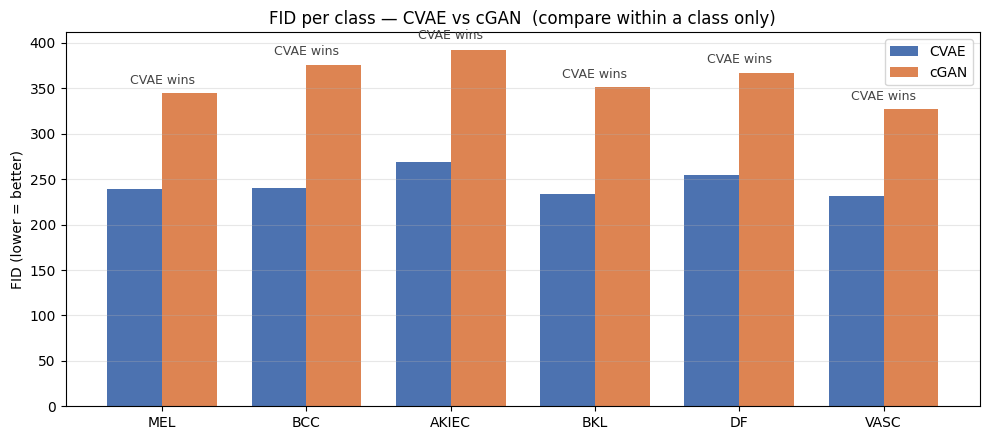

In [5]:
scored = fid_df.dropna(subset=['fid_cvae', 'fid_cgan'], how='all').copy()

if len(scored) > 0:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    x = np.arange(len(scored))
    w = 0.38
    ax.bar(x - w/2, scored['fid_cvae'], width=w, label='CVAE', color='#4C72B0')
    ax.bar(x + w/2, scored['fid_cgan'], width=w, label='cGAN', color='#DD8452')
    ax.set_xticks(x); ax.set_xticklabels(scored['class_name'])
    ax.set_ylabel('FID (lower = better)')
    ax.set_title('FID per class — CVAE vs cGAN  (compare within a class only)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # Annotate the winner per class
    for i, (_, r) in enumerate(scored.iterrows()):
        if pd.notna(r['fid_cvae']) and pd.notna(r['fid_cgan']):
            winner = 'CVAE' if r['fid_cvae'] < r['fid_cgan'] else 'cGAN'
            y = max(r['fid_cvae'], r['fid_cgan']) * 1.03
            ax.text(i, y, f'{winner} wins', ha='center', fontsize=9, color='#444')

    plt.tight_layout()
    out = RESULTS / 'plots' / 'fid_per_class.png'
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'saved {out}')
    plt.show()
else:
    print('No classes had synthetic samples from either source — skipped bar chart.')

## 6. Side-by-side visual: real | CVAE | cGAN, per class

This is the figure that goes in the report. FID is a number; this is the eyeball test.

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/real_vs_synthetic_grid.png


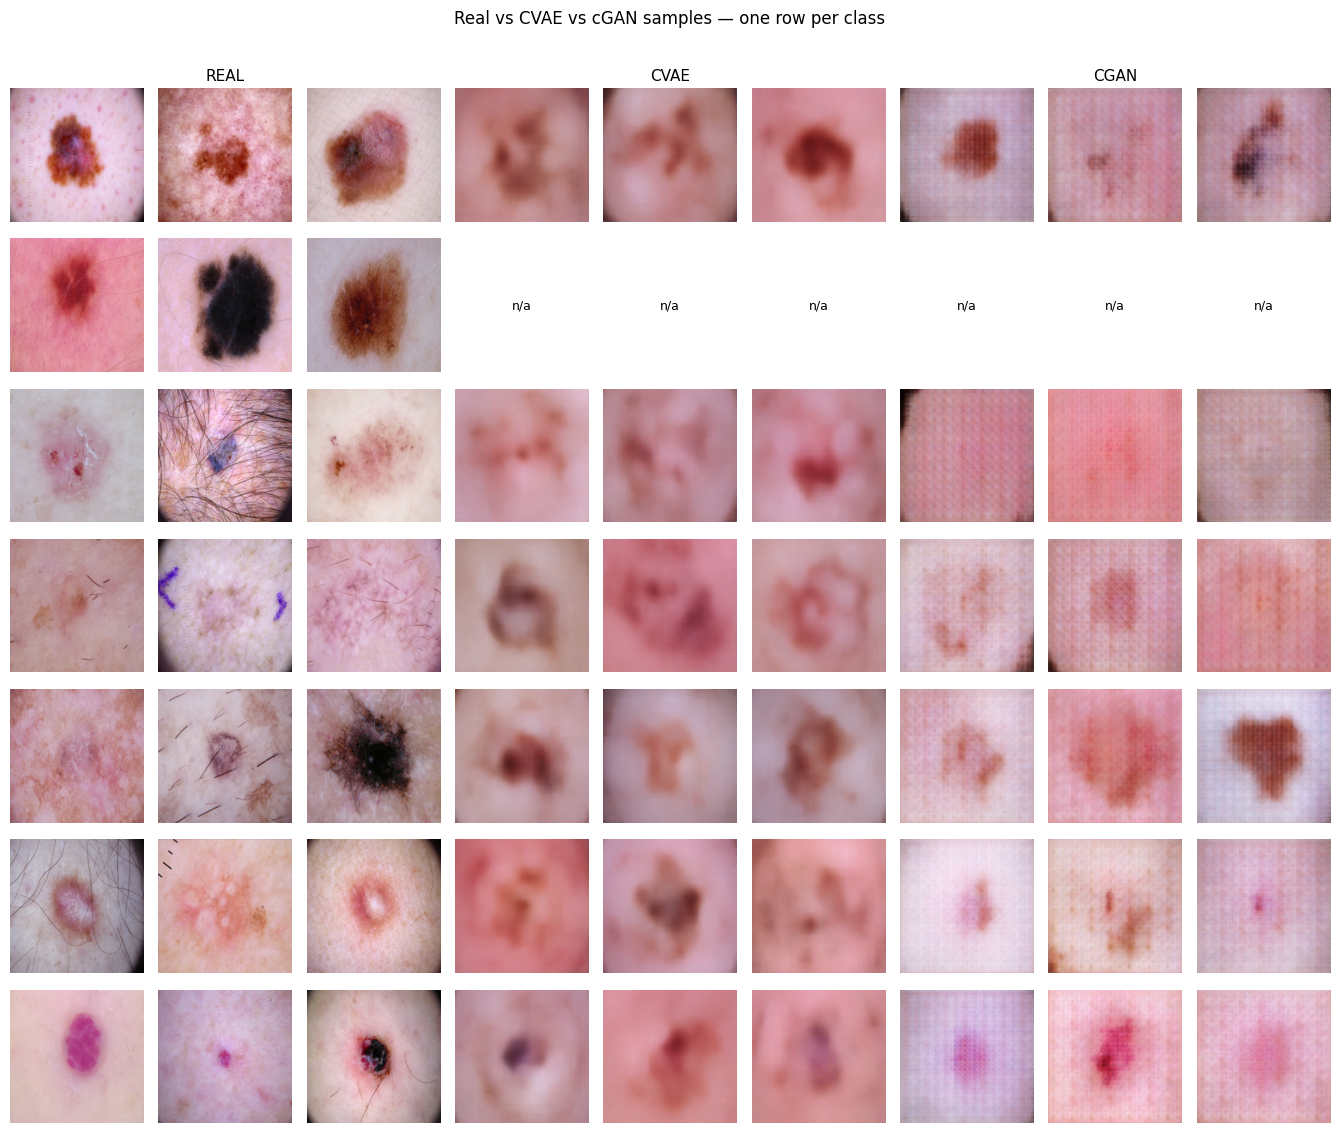

In [6]:
N_PER_PANEL = 3   # 3 real + 3 cvae + 3 cgan per class row

def pick(paths, n):
    if not paths: return []
    rng = np.random.default_rng(SEED)
    return [paths[i] for i in rng.choice(len(paths), size=min(n, len(paths)), replace=False)]

n_cols = 3 * N_PER_PANEL
n_rows = len(CLASS_NAMES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.5 * n_cols, 1.6 * n_rows))

for c, name in enumerate(CLASS_NAMES):
    panels = [
        ('real', pick(real_paths_for(c),         N_PER_PANEL)),
        ('cvae', pick(synth_paths_for('cvae', c), N_PER_PANEL)),
        ('cgan', pick(synth_paths_for('cgan', c), N_PER_PANEL)),
    ]
    for p_idx, (label, paths) in enumerate(panels):
        for j in range(N_PER_PANEL):
            col = p_idx * N_PER_PANEL + j
            ax = axes[c, col]
            if j < len(paths):
                ax.imshow(Image.open(paths[j]).convert('RGB').resize((224, 224)))
            else:
                ax.set_facecolor('#eee')
                ax.text(0.5, 0.5, 'n/a', ha='center', va='center', fontsize=9)
            ax.axis('off')
            if c == 0 and j == 1:
                ax.set_title(label.upper(), fontsize=11)
        # Class label on far left
        if p_idx == 0:
            axes[c, 0].set_ylabel(name, fontsize=11, rotation=0, labelpad=30, va='center')

plt.suptitle('Real vs CVAE vs cGAN samples — one row per class', y=1.01)
plt.tight_layout()
out = RESULTS / 'plots' / 'real_vs_synthetic_grid.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## 7. Results & interpretation

CVAE outperforms cGAN on every class — and by a wide margin. Here are the scores (lower FID = better):

| Class  | n_real | FID (CVAE) | FID (cGAN) | Winner |
|--------|-------:|------------|------------|--------|
| MEL    | 779    | 238.8      | 344.8      | CVAE   |
| BKL    | 769    | 234.0      | 351.3      | CVAE   |
| BCC    | 360    | 239.9      | 375.6      | CVAE   |
| VASC   | 99     | 231.9      | 327.6      | CVAE   |
| DF     | 80     | 255.1      | 366.6      | CVAE   |
| AKIEC  | 229    | 269.3      | 392.1      | CVAE   |

NV was skipped — we didn't generate synthetic NV images since it's already the dominant class.

The absolute FID values are high across the board, which is expected: FID is biased upward on small real-sample sizes, and our rarest classes (DF: 80, VASC: 99) are well below the 10 k+ images typically used to get stable estimates. The numbers are only meaningful *within* a class — comparing CVAE vs cGAN for the same class, where the real-side sample size is identical for both.

The visual grid confirms the ranking: CVAE samples show recognisable skin-lesion texture and colour, while cGAN samples at epoch 30 (the best snapshot before mode collapse) are patchier and lower-contrast. Based on both FID and the visual check, we use CVAE-only synthetic images for all augmented classes in Phase 10.